<a href="https://colab.research.google.com/github/Kshitiz-hub-ops/part-1-neural-network-analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/customer_churn_nn.csv')

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2000, 17)

Column Names:
['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']

Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count    

In [4]:
# Target variable info
print("Target Variable: churn")
print("Meaning: 1 = Customer Churned, 0 = Customer Retained")

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

Target Variable: churn
Meaning: 1 = Customer Churned, 0 = Customer Retained

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

Statistical Summary:
       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min       

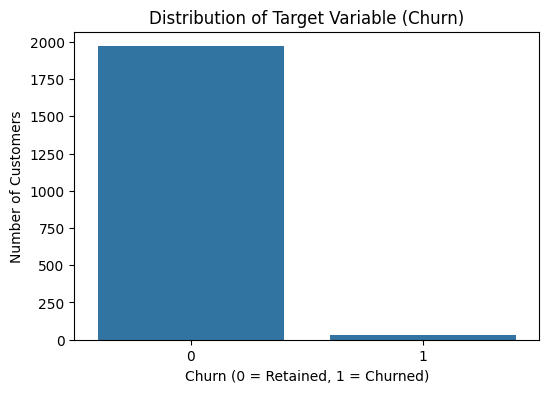

In [5]:
# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)

plt.title('Distribution of Target Variable (Churn)')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Number of Customers')

plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [7]:
df = df.dropna()
print("New Shape After Handling Missing Values:", df.shape)

New Shape After Handling Missing Values: (2000, 17)


In [8]:
df = df.drop('customer_id', axis=1)

In [9]:
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,3,3,0,1,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,4,2,0,4,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,0,3,0,0,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,4,2,0,0,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,2,2,0,2,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [10]:
X = df.drop('churn', axis=1)
y = df['churn']

print(X.shape)
print(y.shape)

(2000, 15)
(2000,)


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 15)
Testing Data Shape: (400, 15)


In [13]:
!pip install tensorflow

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [15]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(15,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9406 - loss: 0.4021 - val_accuracy: 0.9719 - val_loss: 0.2823
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.2200 - val_accuracy: 0.9781 - val_loss: 0.1707
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.1385 - val_accuracy: 0.9781 - val_loss: 0.1296
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.1056 - val_accuracy: 0.9781 - val_loss: 0.1141
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0910 - val_accuracy: 0.9781 - val_loss: 0.1068
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0832 - val_accuracy: 0.9781 - val_loss: 0.1033
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0782 - val_accuracy: 0.9781 - val_loss: 0.1006
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0742 - val_accuracy: 0.9781 - val_loss:

In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.0735  
Test Loss: 0.07354063540697098
Test Accuracy: 0.9825000166893005


In [18]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Training Loss:", history.history['loss'][-1])

Final Training Accuracy: 0.9867187738418579
Final Training Loss: 0.051917970180511475


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


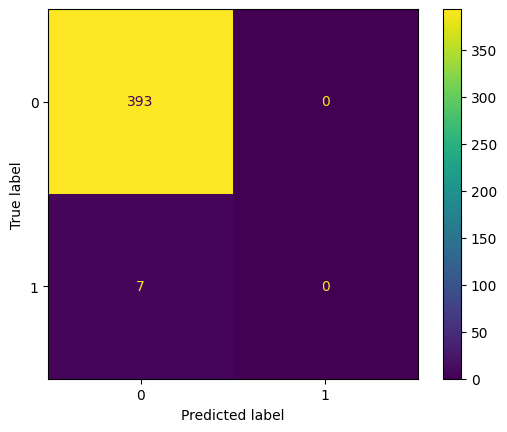

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

Interpretation:
The model achieved good overall accuracy, but the confusion matrix shows that it predicted only the majority class (non-churn). Since the dataset is highly imbalanced, accuracy alone is not enough to judge performance.

In [20]:
model2 = Sequential([
    Dense(32, activation='relu', input_shape=(15,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

print("Experiment 2 Accuracy:", acc2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 2 Accuracy: 0.9825000166893005


In [21]:
model3 = Sequential([
    Dense(16, activation='tanh', input_shape=(15,)),
    Dense(8, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)

print("Experiment 3 Accuracy:", acc3)

Experiment 3 Accuracy: 0.9825000166893005


In [22]:
import pandas as pd

comparison = pd.DataFrame({
    'Experiment': ['Baseline', 'Experiment 2', 'Experiment 3'],
    'Hidden Layers': ['16-8', '32-16', '16-8'],
    'Activation': ['ReLU', 'ReLU', 'Tanh'],
    'Epochs': [20, 30, 20],
    'Batch Size': [32, 32, 64],
    'Test Accuracy': [
        test_accuracy,
        acc2,
        acc3
    ]
})

comparison

,Experiment,Hidden Layers,Activation,Epochs,Batch Size,Test Accuracy
0,Baseline,16-8,ReLU,20,32,0.9825
1,Experiment 2,32-16,ReLU,30,32,0.9825
2,Experiment 3,16-8,Tanh,20,64,0.9825


In [23]:
comparison.to_csv('model_comparison_table.csv', index=False)

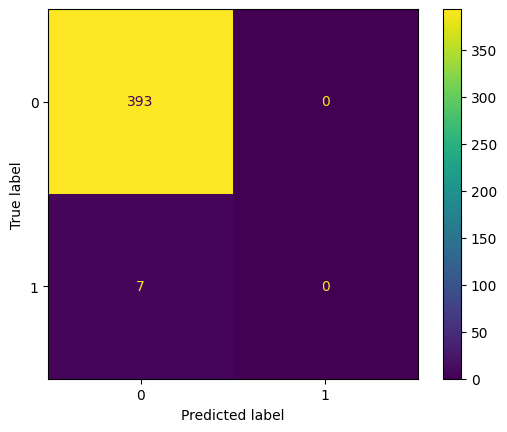

In [24]:
disp.plot()
plt.savefig('evaluation_outputs.png')
plt.show()